In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nasa-cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/x.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CM

In [3]:
import pandas as pd

parent_path = '/kaggle/input/nasa-cmaps/CMaps/'

FD_ID = "FD001" # Conditions: ONE (Sea Level), Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD002" # Conditions: SIX, Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD003" # Conditions: ONE (Sea Level), Fault Modes: TWO (HPC Degradation, Fan Degradation)
#FD_ID = "FD004" # Conditions: SIX , Fault Modes: TWO (HPC Degradation, Fan Degradation)

train_path = parent_path+"train_"+FD_ID+".txt"
test_path  = parent_path+"test_"+FD_ID+".txt"
rul_path   = parent_path+"RUL_"+FD_ID+".txt"

col_names = [
    "unit_number", "time_in_cycles",
    "op_setting_1", "op_setting_2", "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=col_names)
rul_df = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])

# labelling

In [4]:
rename_dict = {
    "op_setting_1": "Alt[kft]", # Altitude
    "op_setting_2": "Mn[-]", # Mach number
    "op_setting_3": "TLA[deg]", # Thrust lever angle (detent?)
    "sensor_1": "T2[R]",  # Total temperature at fan inlet 
    "sensor_2": "T24[R]", # Total temperature at LPC outlet
    "sensor_3": "T30[R]", # Total temperature at HPC outlet
    "sensor_4": "T50[R]", # Total temperature at LPT outlet
    "sensor_5": "P2[psi]", # Pressure at fan inlet
    "sensor_6": "P15[psi]", # Total pressure in bypass-duct
    "sensor_7": "P30[psi]", # Total pressure at HPC outlet
    "sensor_8": "Nf[rpm]", # Physical fan speed
    "sensor_9": "Nc[rpm]", # Physical core speed
    "sensor_10": "epr[-]", # Engine pressure ratio (P50/P2)
    "sensor_11": "phi[pph/psi]", # Ratio of fuel flow to Ps30, (not pps/psi, but pph/psi)
    "sensor_12": "Ps30[psi]", # Static pressure at HPC outlet
    "sensor_13": "NRf[rpm]", # Corrected fan speed
    "sensor_14": "NRc[rpm]", # Corrected core speed
    "sensor_15": "BPR[-]", # Bypass Ratio
    "sensor_16": "farB[-]", # Burner fuel-air ratio
    "sensor_17": "htBleed[]",# Bleed Enthalpy
    "sensor_18": "Nf_dmd[rpm]", # Demanded fan speed
    "sensor_19": "PCNfR_dmd[Pct]", # Demanded corrected fan speed
    "sensor_20": "W31[lbm/s]", # HPT coolant bleed
    "sensor_21": "W32[lbm/s]", # LPT coolant bleed
}


train_df = train_df.rename(columns=rename_dict)
test_df  = test_df.rename(columns=rename_dict)

def clean_round(series, ndigits=1, eps=1e-6):
    """Round values and force -0.0 to 0.0"""
    rounded = series.round(ndigits)
    rounded[rounded.abs() < eps] = 0
    return rounded

train_df['condition'] = (
    clean_round(train_df["Alt[kft]"], 0).astype(str) + '_' +
    clean_round(train_df["Mn[-]"], 1).astype(str) + '_' +
    clean_round(train_df["TLA[deg]"], 0).astype(str)
)

train_df


,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],P15[psi],P30[psi],Nf[rpm],Nc[rpm],epr[-],phi[pph/psi],Ps30[psi],NRf[rpm],NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s],condition
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,0.0_0.0_100.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,0.0_0.0_100.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,0.0_0.0_100.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,0.0_0.0_100.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,0.0_0.0_100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,21.61,551.43,2388.19,9065.52,1.3,48.07,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,0.0_0.0_100.0
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,21.61,550.86,2388.23,9065.11,1.3,48.04,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,0.0_0.0_100.0
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,21.61,550.94,2388.24,9065.90,1.3,48.09,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,0.0_0.0_100.0
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,21.61,550.68,2388.25,9073.72,1.3,48.39,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,0.0_0.0_100.0


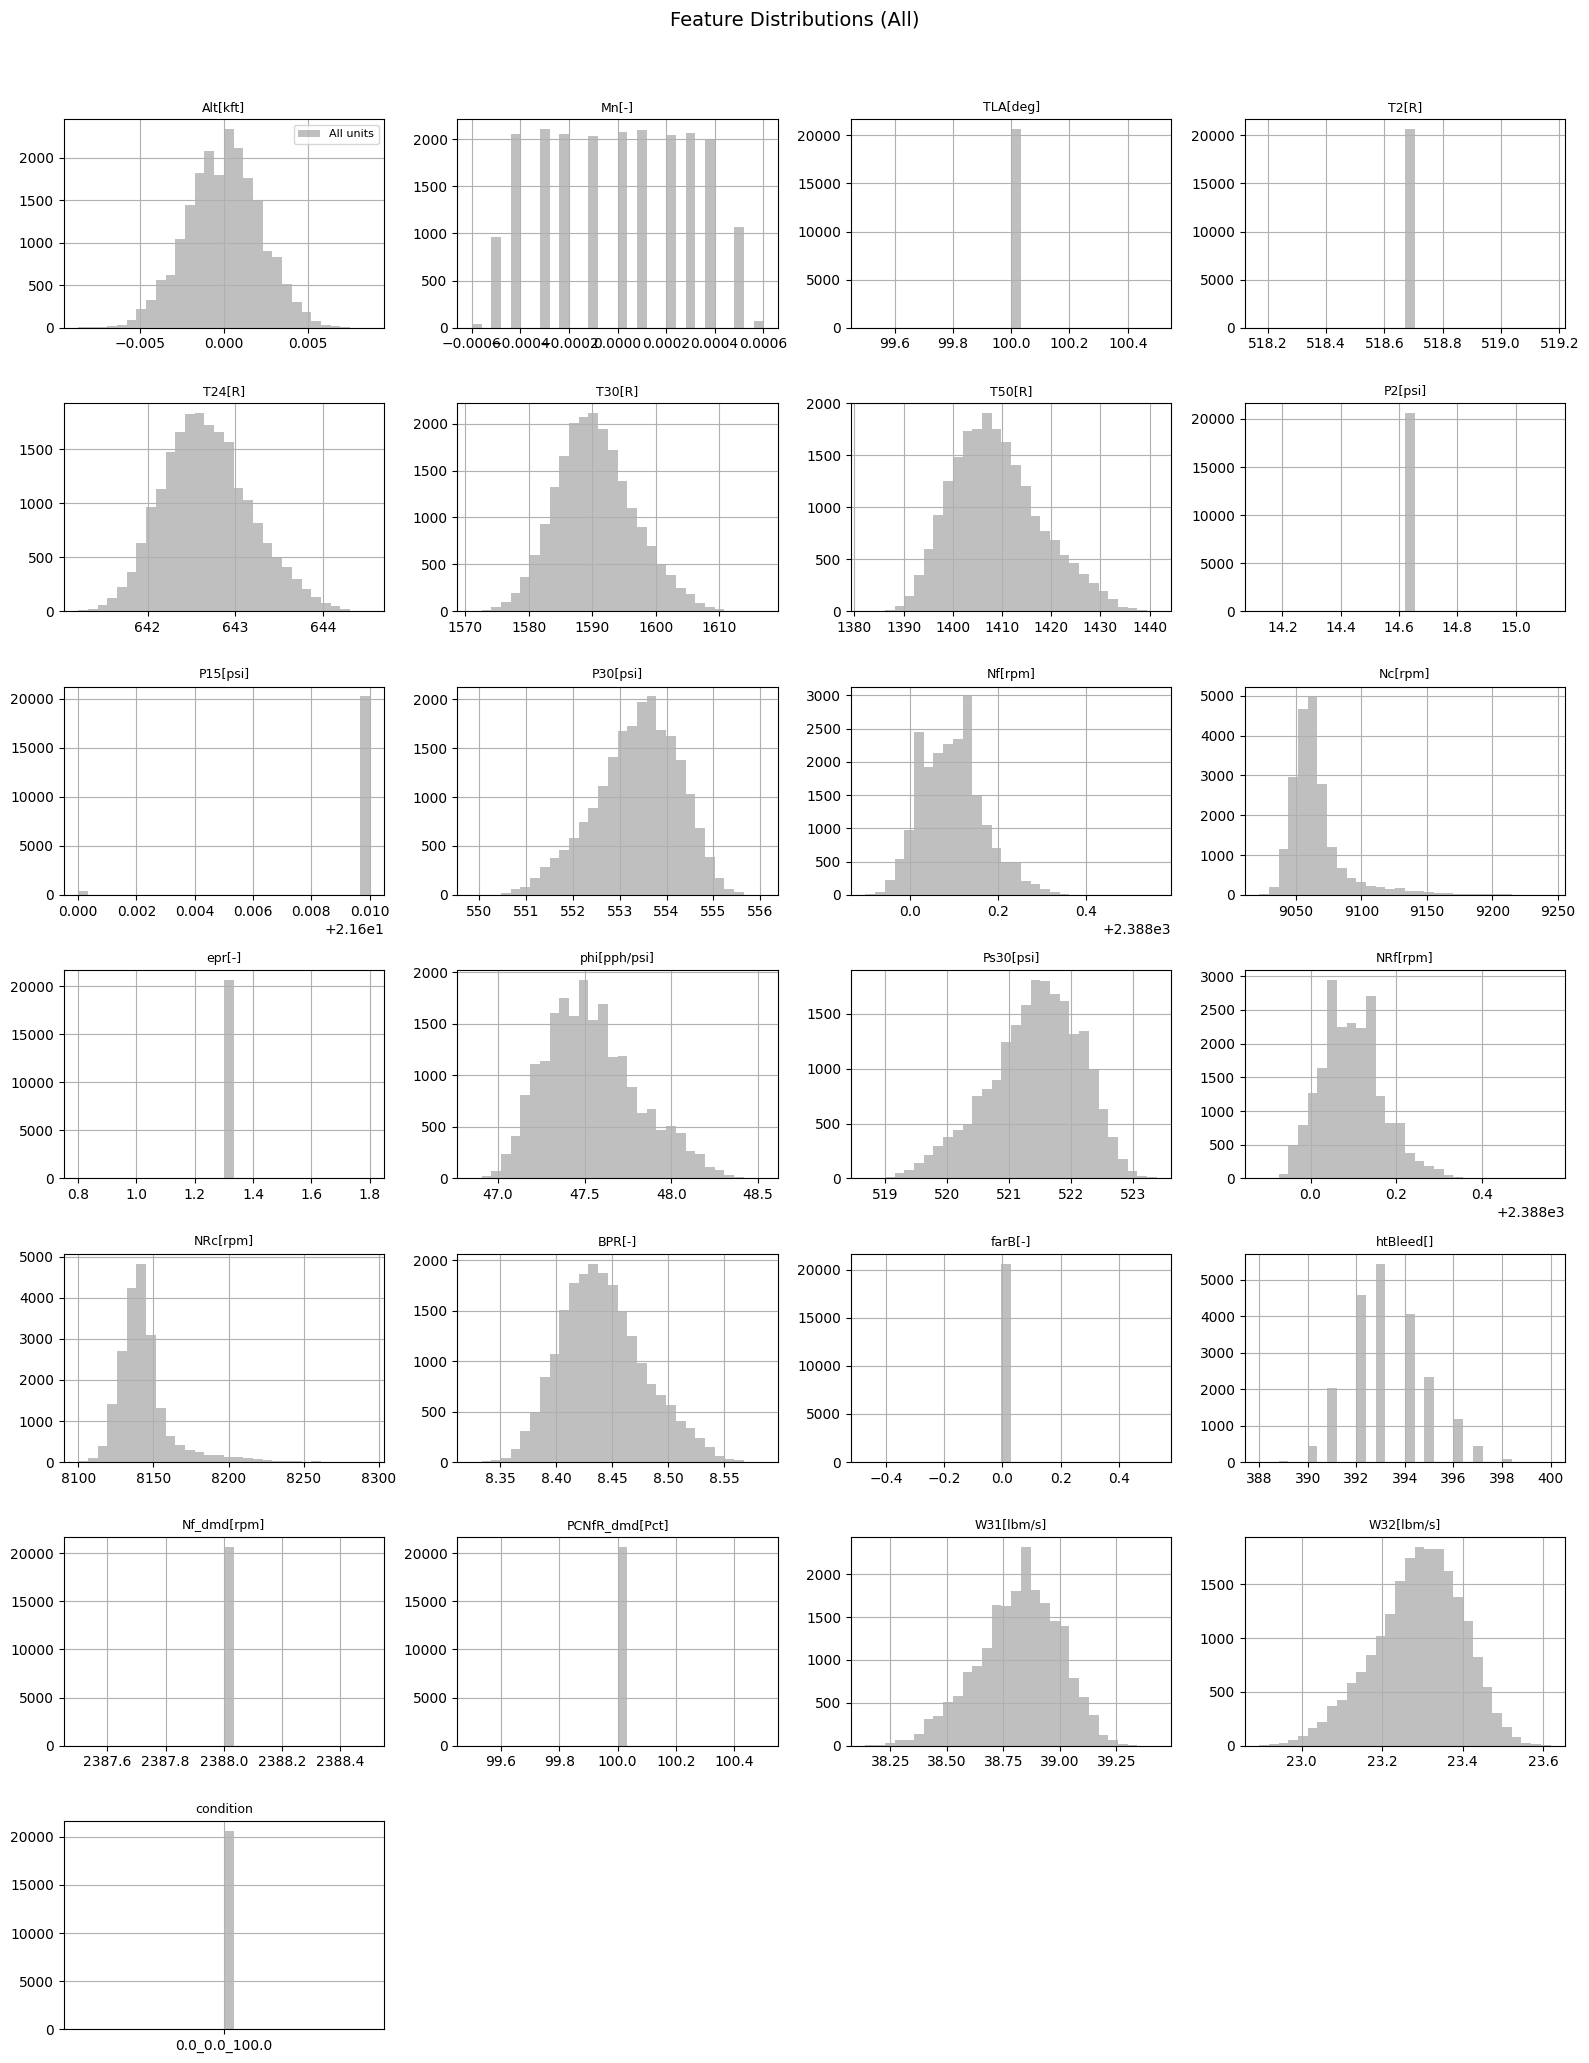

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Select feature columns (exclude unit_number and time_in_cycles)
feature_cols = [col for col in train_df.columns if col not in ["unit_number", "time_in_cycles"]]

rows, cols = 7, 4  # number of rows and columns in the subplot grid

# Choose the unit_number you want to visualize
#unit_id = 1
#df_unit = train_df[train_df["unit_number"] == unit_id]

# Create subplots: 6×4 grid
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
axes = axes.flatten()  # flatten 2D axes array for easy indexing

for i, col in enumerate(feature_cols):
    ax = axes[i]
    
    # compute bin edges from the overall distribution
    #bin_edges = np.linspace(
    #    min(train_df[col].min(), df_unit[col].min()),  # global min
    #    max(train_df[col].max(), df_unit[col].max()),  # global max
    #    30  # number of bins
    #)
    # Plot histogram for all engines (overall distribution)
    #ax.hist(train_df[col], bins=bin_edges, color='gray', alpha=0.5, label='All units')
    ax.hist(train_df[col], bins=30, color='gray', alpha=0.5, label='All units')
    # Plot histogram for the selected unit (overlay)
    #ax.hist(df_unit[col], bins=bin_edges, color='blue', alpha=0.7, label=f'Unit {unit_id}')
    ax.set_title(col, fontsize=9)
    ax.grid(True)

# Hide any remaining empty subplots (if features < rows*cols)
for j in range(i+1, len(axes)):
    axes[j].axis('off')

# Add a main title for the whole figure
#plt.suptitle(f"Feature Distributions (All vs Unit {unit_id})", fontsize=14)
plt.suptitle(f"Feature Distributions (All)", fontsize=14)


# Adjust layout to leave space for the main title
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Optional: add a legend to the first subplot only
axes[0].legend(loc='best', fontsize=8)

plt.show()

# Feature Engineering

In [6]:
train_df["P50[psi]"] = train_df["epr[-]"]*train_df["P2[psi]"]

train_df["Fan.PR[-]"] = train_df["P15[psi]"]/train_df["P2[psi]"]
train_df["LPC.TR[-]"] = train_df["T24[R]"]/train_df["T2[R]"] # Fan core + LPC
train_df["HPC.TR[-]"] = train_df["T30[R]"]/train_df["T24[R]"]

train_df["OPR[-]"] = train_df["P30[psi]"]/train_df["P2[psi]"]

train_df["Wf[pph]"] = train_df["phi[pph/psi]"]*train_df["Ps30[psi]"]
train_df["Wa36[lbm/s]"] = train_df["Wf[pph]"]/3600.0 / train_df["farB[-]"]
train_df["W24[lbm/s]"] = train_df["Wa36[lbm/s]"] + train_df["W31[lbm/s]"] + train_df["W32[lbm/s]"] # core. htBleed ? 
train_df["W15[lbm/s]"] = train_df["W24[lbm/s]"]*train_df["BPR[-]"] # bypass
train_df["W2[lbm/s]"] = train_df["W15[lbm/s]"] + train_df["W24[lbm/s]"] # overall

train_df["WfP3C[pph/psi]"] = train_df["phi[pph/psi]"]/np.sqrt(train_df["T2[R]"]/518.67)

train_df

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],P15[psi],P30[psi],Nf[rpm],Nc[rpm],epr[-],phi[pph/psi],Ps30[psi],NRf[rpm],NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s],condition,P50[psi],Fan.PR[-],LPC.TR[-],HPC.TR[-],OPR[-],Wf[pph],Wa36[lbm/s],W24[lbm/s],W15[lbm/s],W2[lbm/s],WfP3C[pph/psi]
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,0.0_0.0_100.0,19.006,1.478112,1.237434,2.476863,37.917921,24763.2002,229.288891,291.767891,2456.539756,2748.307647,47.47
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,0.0_0.0_100.0,19.006,1.478112,1.238070,2.478891,37.876197,24803.0772,229.658122,292.081722,2462.774665,2754.856388,47.49
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,0.0_0.0_100.0,19.006,1.478112,1.238456,2.472157,37.911081,24694.7934,228.655494,290.949694,2449.156338,2740.106032,47.27
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,0.0_0.0_100.0,19.006,1.478112,1.238456,2.464062,37.924077,24642.3918,228.170294,290.424194,2430.327744,2720.751938,47.13
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,0.0_0.0_100.0,19.006,1.478112,1.238495,2.464078,37.893297,24689.1432,228.603178,290.907578,2452.176336,2743.083914,47.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,21.61,551.43,2388.19,9065.52,1.3,48.07,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,0.0_0.0_100.0,19.006,1.478112,1.240654,2.483302,37.717510,24971.8843,231.221151,292.684651,2486.531720,2779.216371,48.07
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,21.61,550.86,2388.23,9065.11,1.3,48.04,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,0.0_0.0_100.0,19.006,1.478112,1.240750,2.493241,37.678523,24965.4272,231.161363,292.620763,2491.343914,2783.964677,48.04
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,21.61,550.94,2388.24,9065.90,1.3,48.09,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,0.0_0.0_100.0,19.006,1.478112,1.240519,2.490535,37.683995,25007.2809,231.548897,292.922197,2508.761450,2801.683648,48.09
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,21.61,550.68,2388.25,9073.72,1.3,48.39,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,0.0_0.0_100.0,19.006,1.478112,1.240153,2.495624,37.666211,25146.8313,232.841031,294.195031,2512.101946,2806.296977,48.39


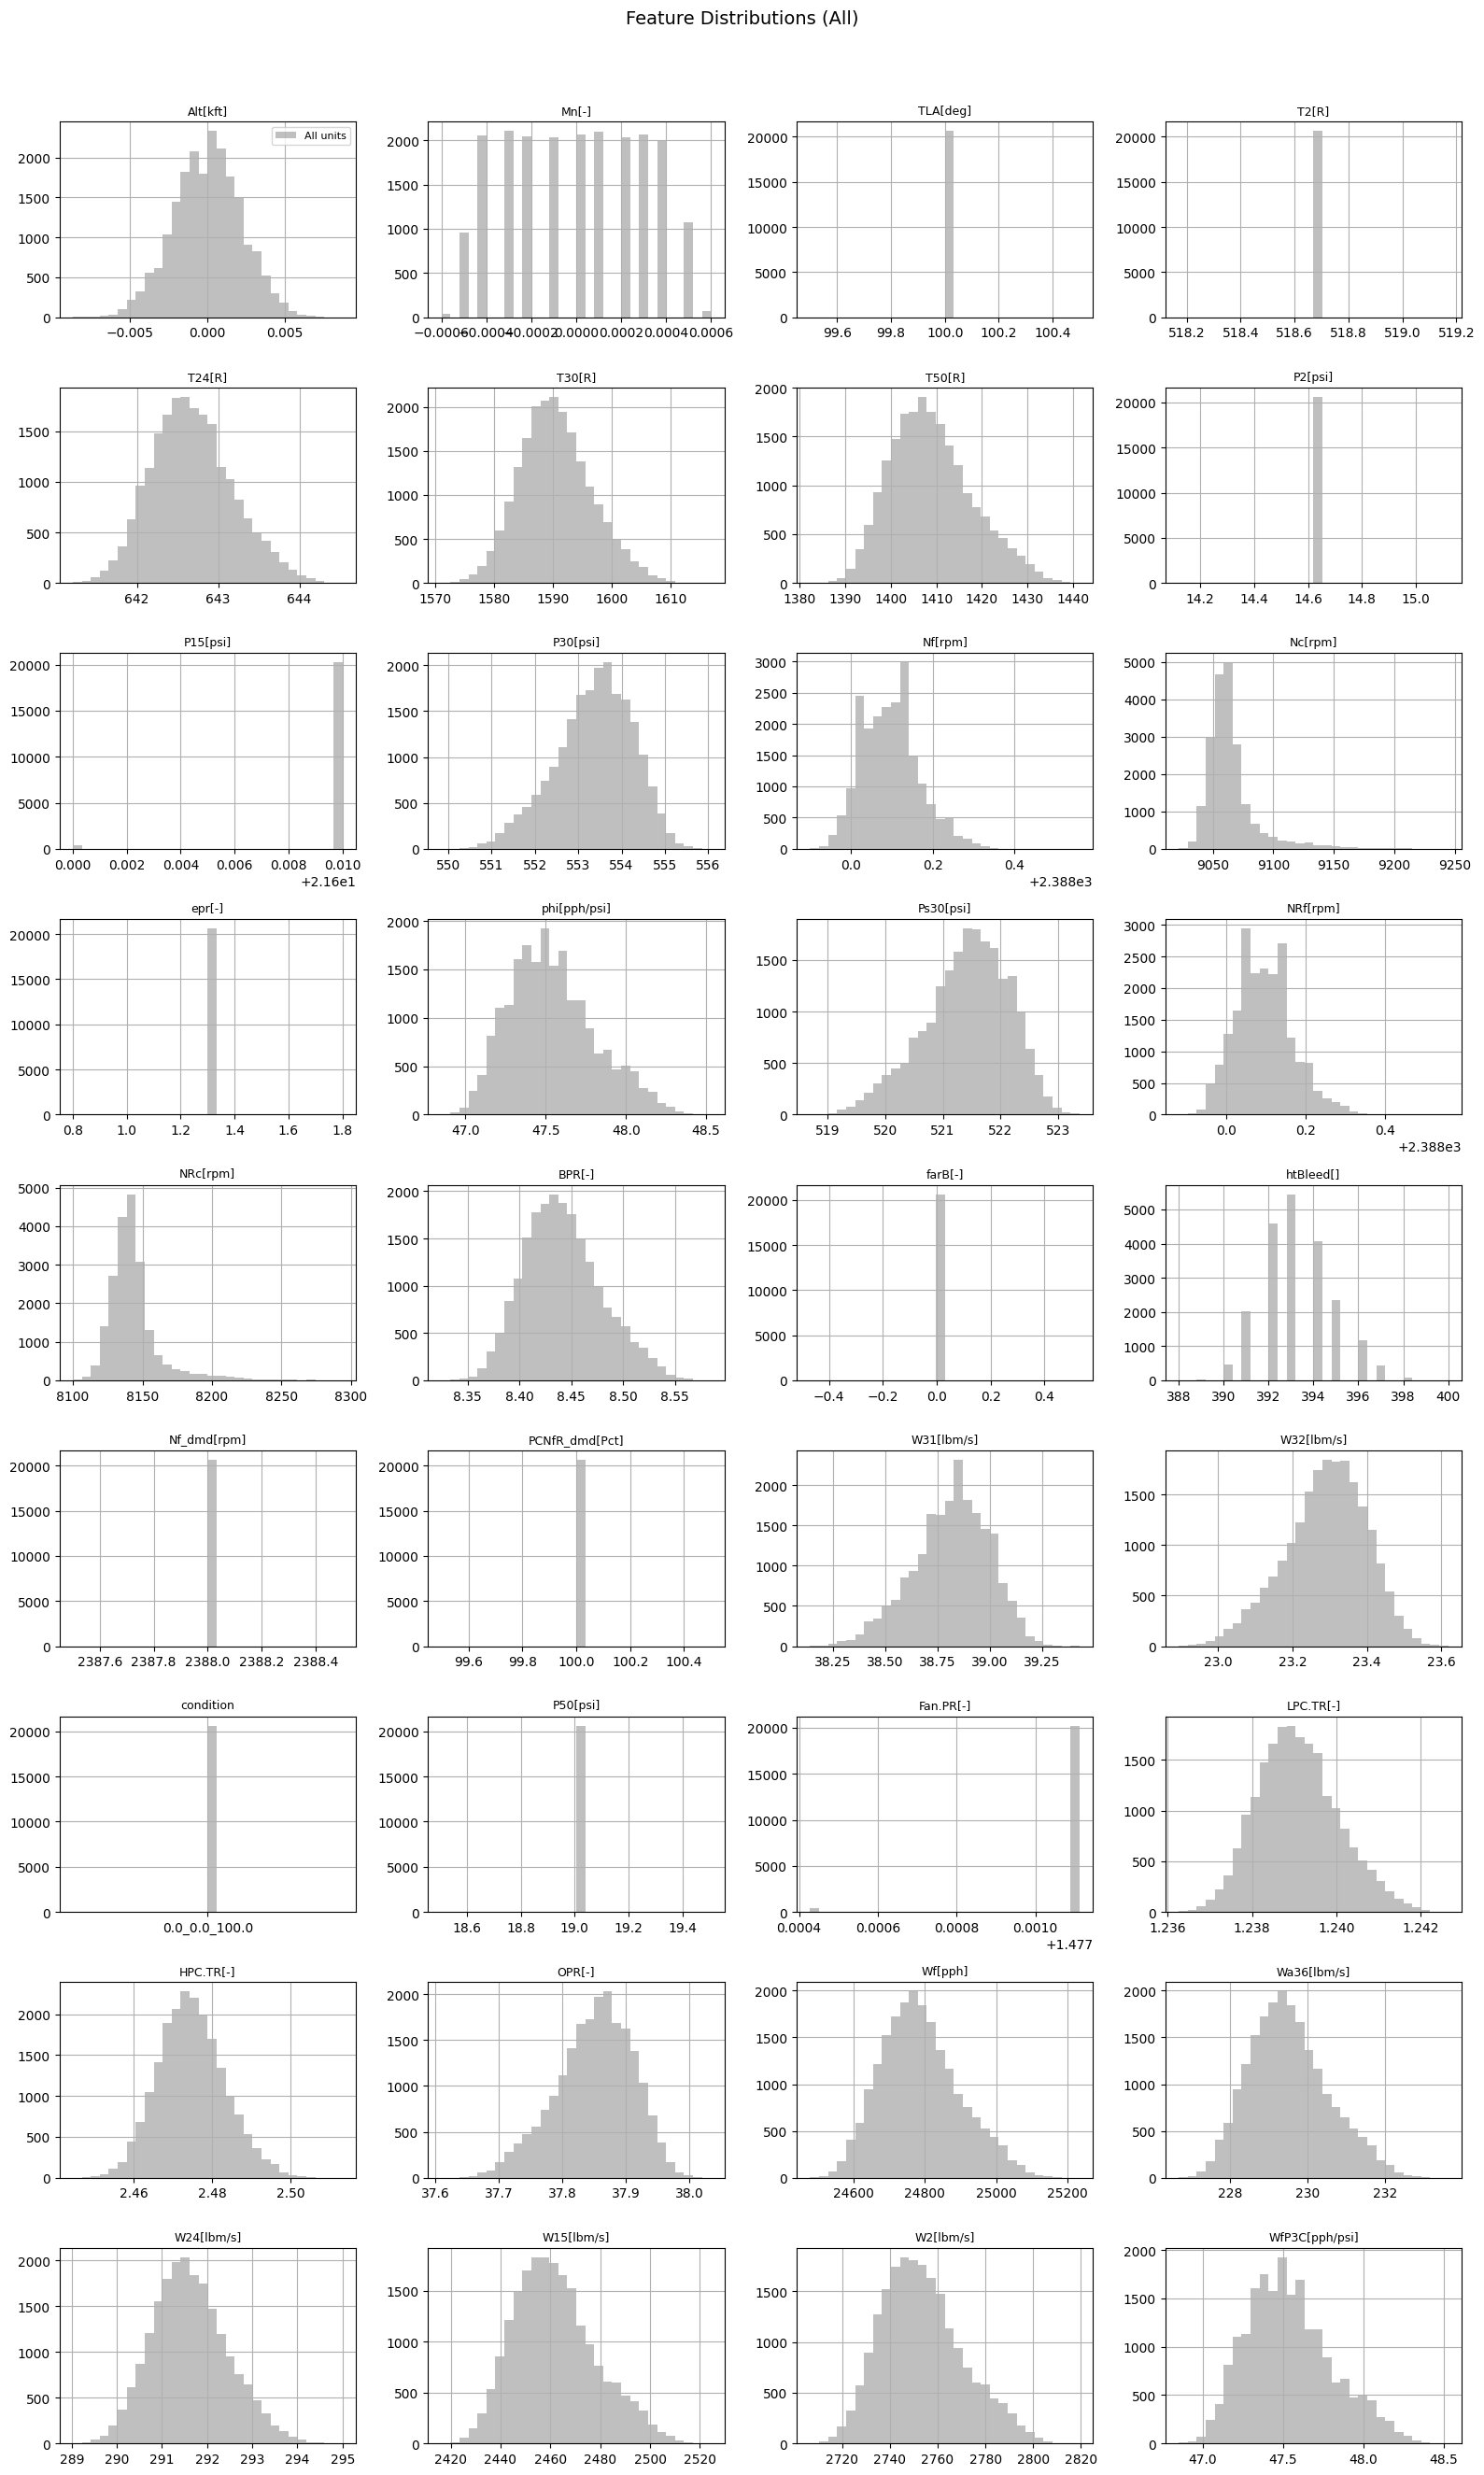

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Select feature columns (exclude unit_number and time_in_cycles)
feature_cols = [col for col in train_df.columns if col not in ["unit_number", "time_in_cycles"]]

rows, cols = 9, 4  # number of rows and columns in the subplot grid

# Choose the unit_number you want to visualize
#unit_id = 1
#df_unit = train_df[train_df["unit_number"] == unit_id]

# Create subplots: 6×4 grid
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
axes = axes.flatten()  # flatten 2D axes array for easy indexing

for i, col in enumerate(feature_cols):
    ax = axes[i]
    
    # compute bin edges from the overall distribution
    #bin_edges = np.linspace(
    #    min(train_df[col].min(), df_unit[col].min()),  # global min
    #    max(train_df[col].max(), df_unit[col].max()),  # global max
    #    30  # number of bins
    #)
    # Plot histogram for all engines (overall distribution)
    #ax.hist(train_df[col], bins=bin_edges, color='gray', alpha=0.5, label='All units')
    ax.hist(train_df[col], bins=30, color='gray', alpha=0.5, label='All units')
    # Plot histogram for the selected unit (overlay)
    #ax.hist(df_unit[col], bins=bin_edges, color='blue', alpha=0.7, label=f'Unit {unit_id}')
    ax.set_title(col, fontsize=9)
    ax.grid(True)

# Hide any remaining empty subplots (if features < rows*cols)
for j in range(i+1, len(axes)):
    axes[j].axis('off')

# Add a main title for the whole figure
#plt.suptitle(f"Feature Distributions (All vs Unit {unit_id})", fontsize=14)
plt.suptitle(f"Feature Distributions (All)", fontsize=14)


# Adjust layout to leave space for the main title
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Optional: add a legend to the first subplot only
axes[0].legend(loc='best', fontsize=8)

plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

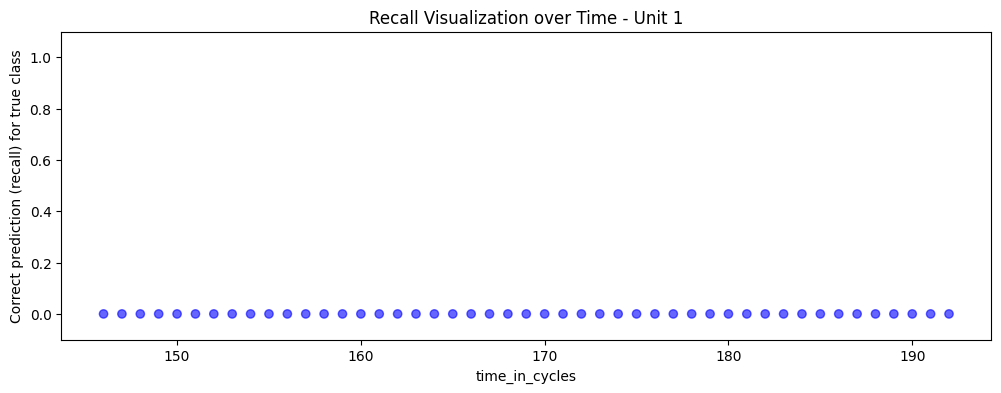

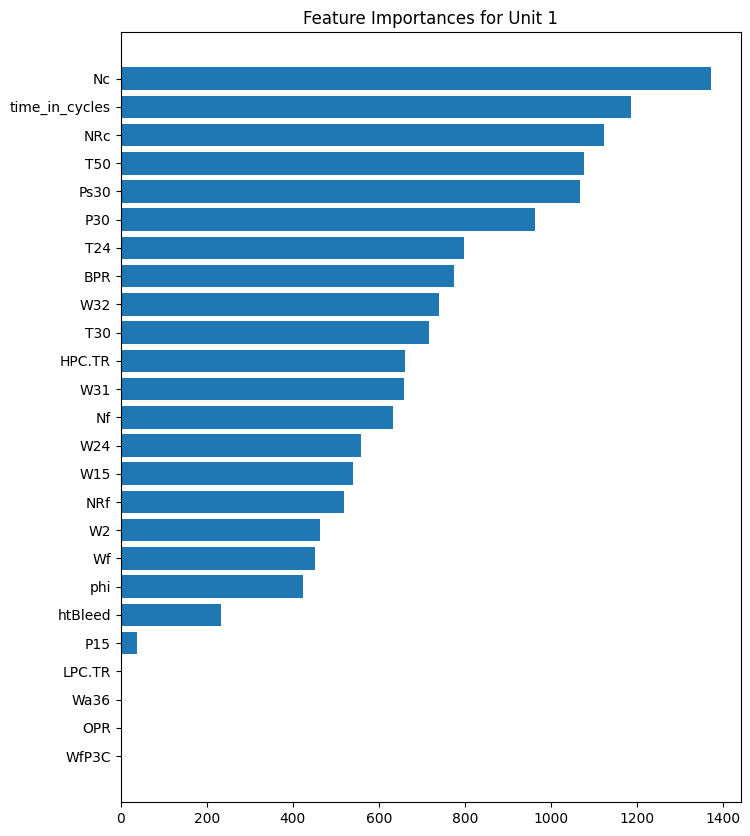

100%|██████████| 1/1 [00:02<00:00,  2.22s/it]


In [8]:
import re
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import tqdm

from sklearn.metrics import recall_score, precision_score, f1_score

threshold = 0.5
scores = []

# --- Preprocessing: sanitize column names ---
train_df_safe = train_df.copy()
train_df_safe.columns = [
    re.sub(r"\[.*?\]", "", col)
    .replace('%','p')
    .replace('-','_')
    for col in train_df_safe.columns
]
train_df_safe.columns = [col.strip() for col in train_df_safe.columns]

# --- Filter to a single condition ---
cond1 = train_df_safe["condition"].unique()[0]
cond1_df = train_df_safe[train_df_safe['condition'] == cond1]

# --- Define features and target ---
feature_cols = [c for c in cond1_df.columns if c not in [
    'unit_number','condition', 'Alt', 'Mn', 'TLA', 'epr', 'T2', 'P2', 
    'Nf_dmd', 'PCNfR_dmd', 'P50', 'farB', 'Fan.PR'
]]
X = cond1_df[feature_cols]
y = cond1_df['unit_number']

# --- Select units to classify ---
unit_ids = [1]  # can expand to all units: sorted(y.unique())

# --- Loop over units for OvR classification ---
for unit in tqdm.tqdm(unit_ids):
    # Binary label for current unit
    y_bin = (y == unit).astype(int)
    
    # Sort by time for time-based train/test split
    cond1_df_sorted = cond1_df.sort_values(by='time_in_cycles')
    X_sorted = cond1_df_sorted[feature_cols].apply(pd.to_numeric, errors='coerce')
    y_sorted = (cond1_df_sorted['unit_number'] == unit).astype(int)
    
    # Train/test split
    train_ratio = 0.7
    n_samples = len(X_sorted)
    train_end = int(n_samples * train_ratio)
    
    X_train = X_sorted.iloc[:train_end]
    y_train = y_sorted.iloc[:train_end]
    X_test  = X_sorted.iloc[train_end:]
    y_test  = y_sorted.iloc[train_end:]
    time_test = cond1_df_sorted['time_in_cycles'].iloc[train_end:]
    
    # --- Train LightGBM classifier ---
    clf = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    )
    clf.fit(X_train, y_train)
    
    # --- Predict on test set ---
    y_pred = clf.predict(X_test)
    y_true = (y_test == unit).astype(int)
    
    r = recall_score(y_true, y_pred)
    p = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    scores.append({"unit": unit, "recall": r, "precision": p, "f1": f1})

    
    # --- Select only true class=1 samples for recall-like visualization ---
    mask_true = (y_test == 1)
    correct_true = (y_pred[mask_true] == y_test[mask_true]).astype(int)
    time_true = time_test[mask_true]
    
    # --- Plot recall for true samples ---
    plt.figure(figsize=(12, 4))
    plt.scatter(time_true, correct_true, c=correct_true, cmap='bwr', alpha=0.6)
    plt.xlabel('time_in_cycles')
    plt.ylabel('Correct prediction (recall) for true class')
    plt.title(f'Recall Visualization over Time - Unit {unit}')
    plt.ylim(-0.1, 1.1)
    plt.show()
    
    # --- Feature importance ---
    feature_importances = pd.DataFrame({
        'feature': X_train.columns,
        'importance': clf.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(8, 10))
    plt.barh(feature_importances['feature'], feature_importances['importance'])
    plt.gca().invert_yaxis()
    plt.title(f'Feature Importances for Unit {unit}')
    plt.show()

scores_df_after = pd.DataFrame(scores)

In [9]:
print(scores_df_after)

   unit  recall  precision   f1
0     1     0.0        0.0  0.0


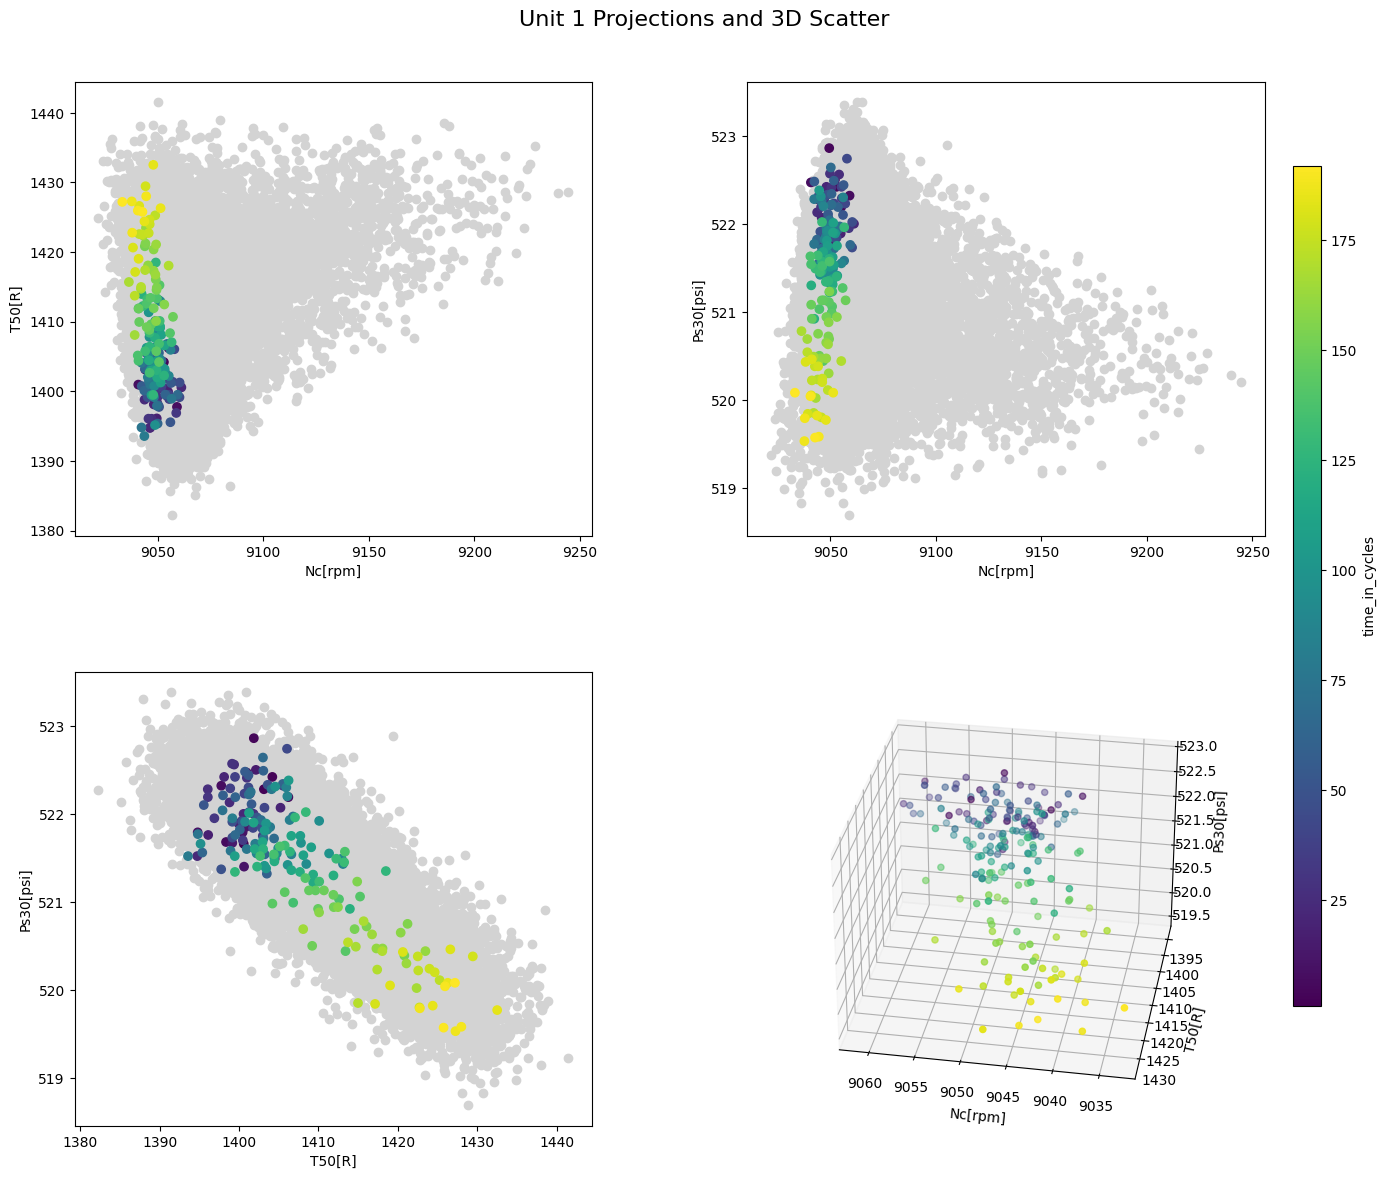

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# --- Columns ---
x_label = "Nc[rpm]"
y_label = "T50[R]"
z_label = "Ps30[psi]"
c_label = "time_in_cycles"

# --- Select one unit ---
unit_id = train_df["unit_number"].unique()[0]
df_unit = train_df[train_df["unit_number"] == unit_id]

c = df_unit[c_label].values

# --- Data ---
x = df_unit[x_label].values
y = df_unit[y_label].values
z = df_unit[z_label].values
c = df_unit[c_label].values

x_all = train_df[x_label].values
y_all = train_df[y_label].values
z_all = train_df[z_label].values
c_all = train_df[c_label].values

fig = plt.figure(figsize=(14, 12))

# --- 2D: XY ---
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(x_all, y_all, c='lightgray')
sc1 = ax1.scatter(x, y, c=c, cmap='viridis')
ax1.set_xlabel(x_label)
ax1.set_ylabel(y_label)
#ax1.set_title("XY Projection")

# --- 2D: XZ ---
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(x_all, z_all, c='lightgray')
sc2 = ax2.scatter(x, z, c=c, cmap='viridis')
ax2.set_xlabel(x_label)
ax2.set_ylabel(z_label)
#ax2.set_title("XZ Projection")

# --- 2D: YZ ---
ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(y_all, z_all, c='lightgray')
sc3 = ax3.scatter(y, z, c=c, cmap='viridis')
ax3.set_xlabel(y_label)
ax3.set_ylabel(z_label)
#ax3.set_title("YZ Projection")

# --- 3D scatter ---
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
sc4 = ax4.scatter(x, y, z, c=c, cmap='viridis')
#ax4.scatter(x_all, y_all, z_all, c='lightgray', alpha=0.1)
ax4.set_xlabel(x_label)
ax4.set_ylabel(y_label)
ax4.set_zlabel(z_label)
#ax4.set_title("3D Scatter")
ax4.view_init(elev=30, azim=100)

# --- Colorbar ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = plt.colorbar(sc4, cax=cbar_ax)
cbar.set_label(c_label)

# --- Overall title ---
fig.suptitle(f"Unit {unit_id} Projections and 3D Scatter", fontsize=16)

# --- Adjust layout ---
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, hspace=0.3, wspace=0.3)

plt.show()

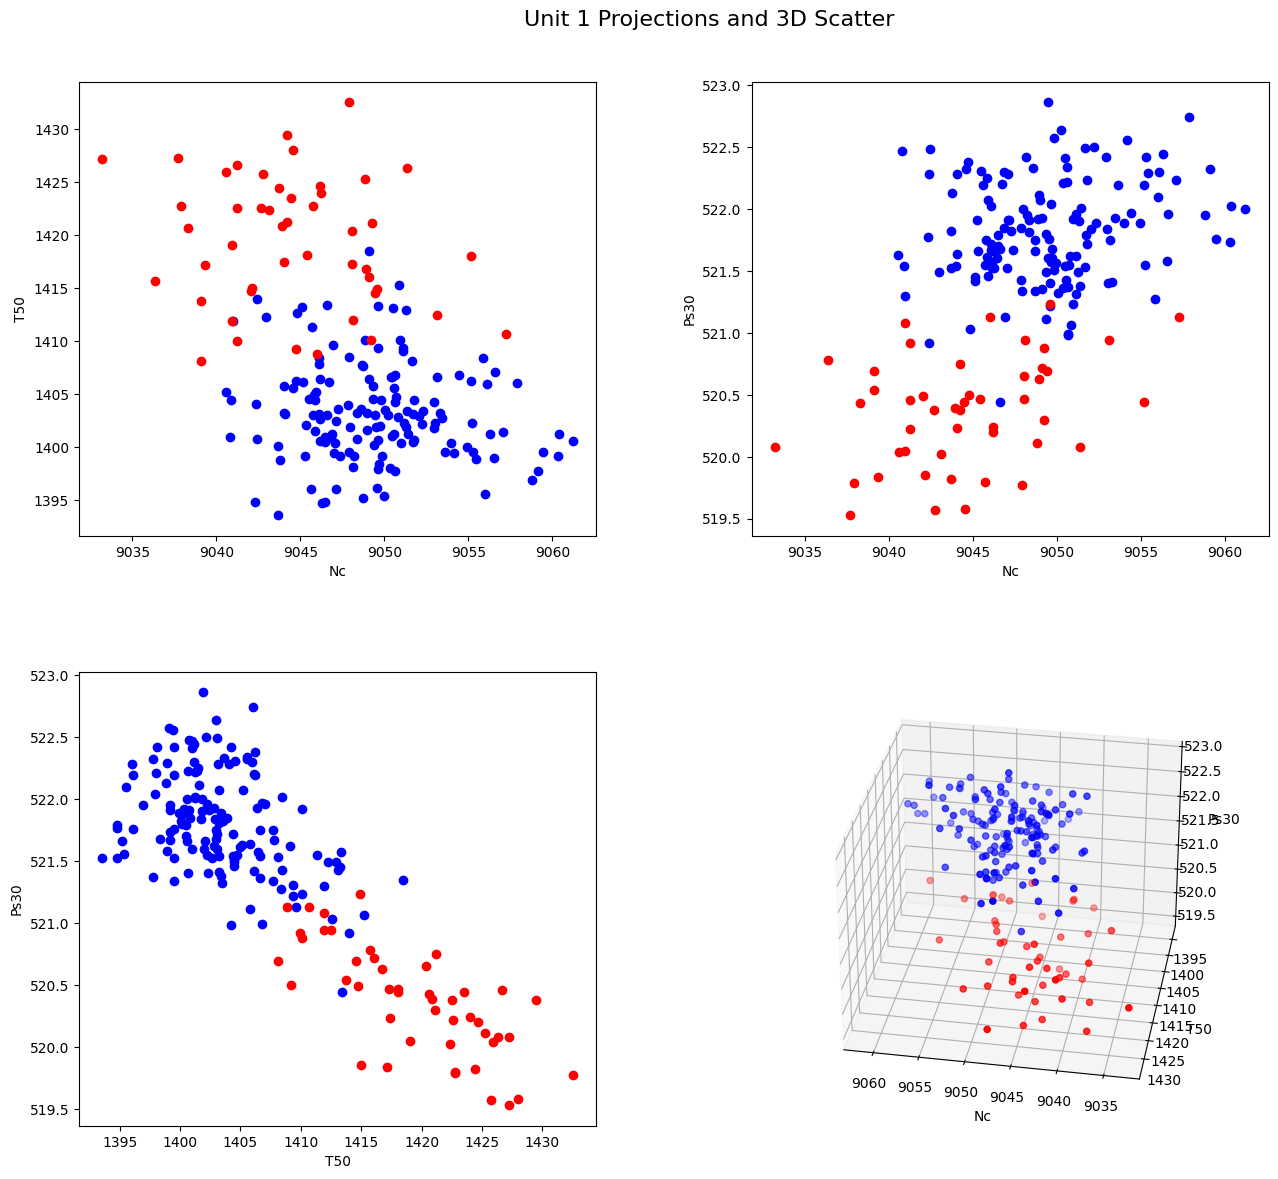

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# --- Columns ---
x_label = "Nc"
y_label = "T50"
z_label = "Ps30"
# c_label = "time_in_cycles"

# --- Data ---
unit_id = 1
x_old = X_train[y_train==unit_id][x_label].values
y_old = X_train[y_train==unit_id][y_label].values
z_old = X_train[y_train==unit_id][z_label].values
c_old = X_train[y_train==unit_id][c_label].values

x_new = X_test[y_test==unit_id][x_label].values
y_new = X_test[y_test==unit_id][y_label].values
z_new = X_test[y_test==unit_id][z_label].values
c_new = X_test[y_test==unit_id][c_label].values

fig = plt.figure(figsize=(14, 12))

# --- 2D: XY ---
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(x_old, y_old, c='blue')
ax1.scatter(x_new, y_new, c='red')
ax1.set_xlabel(x_label)
ax1.set_ylabel(y_label)
#ax1.set_title("XY Projection")

# --- 2D: XZ ---
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(x_old, z_old, c='blue')
ax2.scatter(x_new, z_new, c='red')
ax2.set_xlabel(x_label)
ax2.set_ylabel(z_label)
#ax2.set_title("XZ Projection")

# --- 2D: YZ ---
ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(y_old, z_old, c='blue')
ax3.scatter(y_new, z_new, c='red')
ax3.set_xlabel(y_label)
ax3.set_ylabel(z_label)
#ax3.set_title("YZ Projection")

# --- 3D scatter ---
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.scatter(x_old, y_old, z_old, c='blue')
ax4.scatter(x_new, y_new, z_new, c='red')
ax4.set_xlabel(x_label)
ax4.set_ylabel(y_label)
ax4.set_zlabel(z_label)
#ax4.set_title("3D Scatter")
ax4.view_init(elev=30, azim=100)

# --- Overall title ---
fig.suptitle(f"Unit {unit_id} Projections and 3D Scatter", fontsize=16)

# --- Adjust layout ---
fig.subplots_adjust(left=0.05, right=0.9, top=0.92, bottom=0.05, hspace=0.3, wspace=0.3)

plt.show()

The old data and the new data lie on the same trend, but their positions differ. -> degrade